In [17]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd 

In [18]:
from sklearn.model_selection import train_test_split as ts
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [19]:
df=pd.read_csv('admission.csv')
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


In [20]:
desc=df['Chance of Admit '].describe()
threshold=desc["75%"] 
df['admitted']=(df['Chance of Admit ']>=threshold).astype(int)
df.drop(["Chance of Admit ","Serial No."],axis=1,inplace=True)
df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,admitted
0,337,118,4,4.5,4.5,9.65,1,1
1,324,107,4,4.0,4.5,8.87,1,0
2,316,104,3,3.0,3.5,8.00,1,0
3,322,110,3,3.5,2.5,8.67,1,0
4,314,103,2,2.0,3.0,8.21,0,0
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,0
396,325,107,3,3.0,3.5,9.11,1,1
397,330,116,4,5.0,4.5,9.45,1,1
398,312,103,3,3.5,4.0,8.78,0,0


In [21]:
x=df.drop(['admitted'],axis=1)
y=df['admitted']

In [22]:
x_train,x_test,y_train,y_test=ts(x,y,test_size=0.2,random_state=42)

In [32]:
model=DecisionTreeClassifier(criterion='gini',random_state=42,max_depth=3,min_samples_split=4,min_samples_leaf=2)
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,4
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
y_pred_gini=model.predict(x_test)

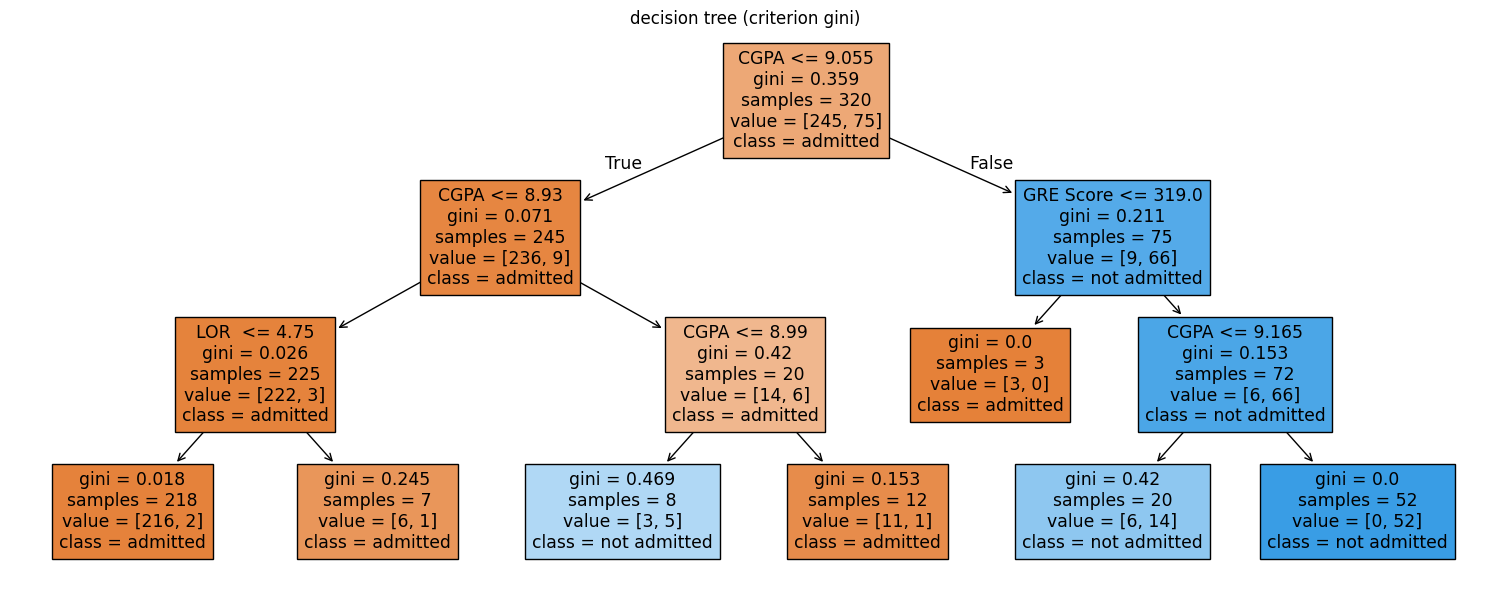

In [36]:
plt.figure(figsize=(15,6))
plot_tree(model,feature_names=x.columns,class_names=['admitted','not admitted'],filled=True)
plt.title("decision tree (criterion gini)")
plt.tight_layout()
plt.show()

In [26]:
print('confusion matrix of gini is /n')
print('accuracy score is :',accuracy_score(y_test,y_pred_gini))
print('confusion matrix is :',confusion_matrix(y_test,y_pred_gini))
print('clasification report is :',classification_report(y_test,y_pred_gini))

confusion matrix of gini is /n
accuracy score is : 0.9625
confusion matrix is : [[52  2]
 [ 1 25]]
clasification report is :               precision    recall  f1-score   support

           0       0.98      0.96      0.97        54
           1       0.93      0.96      0.94        26

    accuracy                           0.96        80
   macro avg       0.95      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80



In [27]:
clf=DecisionTreeClassifier(criterion='entropy',random_state=42,max_depth=3,min_samples_split=4,min_samples_leaf=2)
clf.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,4
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
y_pred_entropy=clf.predict(x_test)

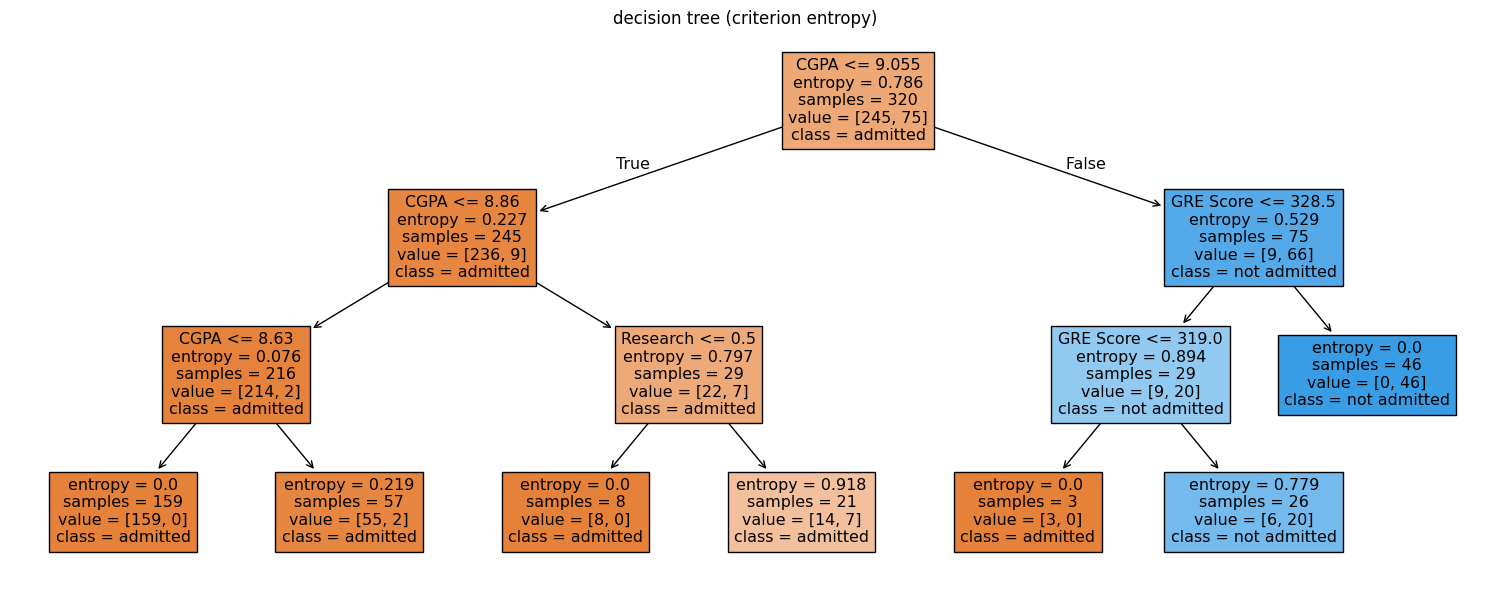

In [29]:
plt.figure(figsize=(15,6))
plot_tree(clf,feature_names=x.columns,class_names=['admitted','not admitted'],filled=True)
plt.title("decision tree (criterion entropy)")
plt.tight_layout()
plt.show()